In [ ]:
%load_ext autoreload
%autoreload 2
    
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from torch.utils.data import TensorDataset
from torch_geometric.loader import DataLoader
from torch_geometric.data import Data
from sklearn.model_selection import train_test_split

import sys
from pathlib import Path

parent_dir = Path.cwd().parent
sys.path.append(str(parent_dir))

import models.gnn as gnn

Load and split a graph dataset with atom-type node features (and activities)

In [4]:

graphs_list = torch.load('../data_collection/graphs_at_types_only.pt', weights_only=False)

graphs_train, graphs_val = train_test_split(
    graphs_list,
    test_size=0.10,     
    random_state=42     
)


train_loader = DataLoader(
    graphs_train, 
    batch_size=300,   
    shuffle=True   
)

val_loader = DataLoader(
    graphs_val, 
    batch_size=300,   
    shuffle=True   
)

device = torch.device("cpu")

Train a custom model with SAGEConv layers (see ../models/gnn.py) to predict activity values

In [5]:
epochs = 500
model = gnn.SAGEC(16, 256, 128, 16, 1).to(device)
model.fit(train_loader, val_loader, device, epochs=epochs) #early stopping applied

 32%|███████████████████████████████████████████████████▊                                                                                                               | 159/500 [03:56<08:27,  1.49s/it]


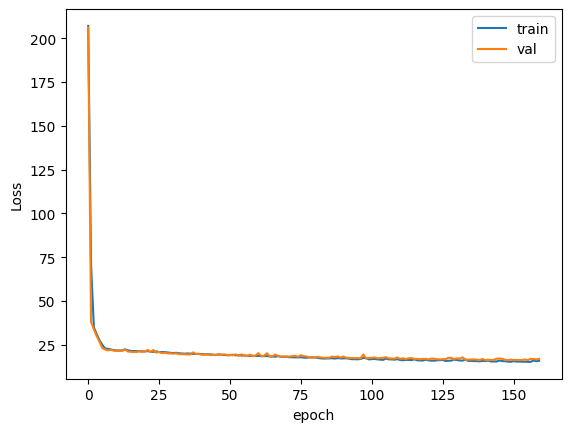

R² Train Score: 0.464
Train RMSE:     ±0.734
Train MAE:      ±0.549
R² Val Score: 0.417
Val RMSE:     ±0.761
Val MAE:      ±0.585


In [9]:
plt.plot(model.train_loss, label='train')
plt.plot(model.val_loss, label='val')

plt.legend()
plt.xlabel('epoch')
plt.ylabel('Loss')
plt.xticks(range(0, len(model.val_loss), 25))
plt.show()

model.eval()
model.analysis(train_loader, val_loader, device)

Train a custom model with GINConv layers (see ../models/gnn.py) to predict activity values

In [43]:
epochs = 500
model = gnn.GINConv(16, 256, 128, 16, 1).to(device)
model.fit(train_loader, val_loader, device, epochs=epochs, tol=0.3)

 78%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                                    | 388/500 [09:37<02:46,  1.49s/it]


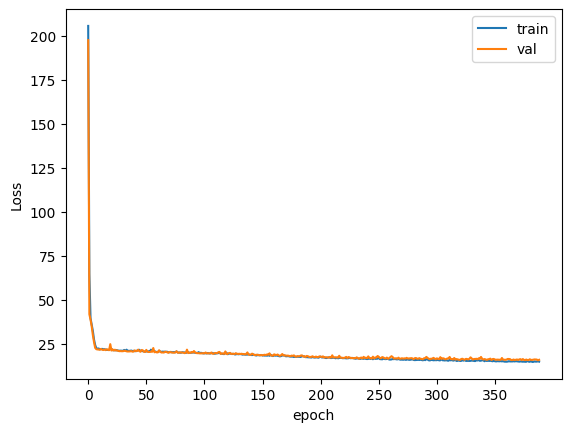

R² Train Score: 0.508
Train RMSE:     ±0.703
Train MAE:      ±0.522
R² Val Score: 0.457
Val RMSE:     ±0.734
Val MAE:      ±0.556


In [44]:
plt.plot(model.train_loss, label='train')
plt.plot(model.val_loss, label='val')

plt.legend()
plt.xlabel('epoch')
plt.ylabel('Loss')
plt.xticks(range(0, len(model.val_loss), 50))
plt.show()

model.eval()
model.analysis(train_loader, val_loader, device)

Train a custom model with GraphConv layers (see ../models/gnn.py) to predict activity values

In [24]:
epochs = 500
model = gnn.GraphConv(16, 256, 128, 16, 1).to(device)
model.fit(train_loader, val_loader, device, epochs=epochs) #early stopping applied

 36%|██████████████████████████████████████████████████████████▋                                                                                                        | 180/500 [04:21<07:44,  1.45s/it]


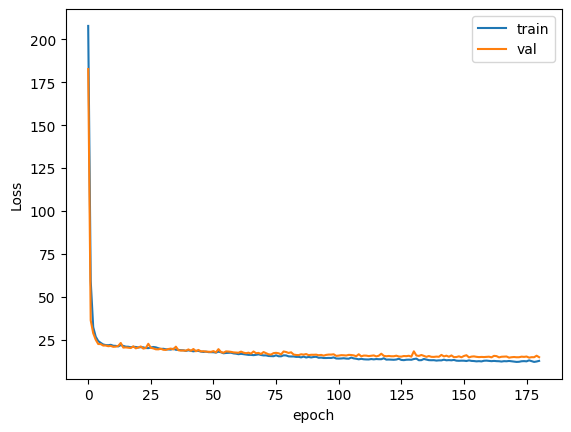

R² Train Score: 0.640
Train RMSE:     ±0.601
Train MAE:      ±0.432
R² Val Score: 0.520
Val RMSE:     ±0.690
Val MAE:      ±0.525


In [26]:
plt.plot(model.train_loss, label='train')
plt.plot(model.val_loss, label='val')

plt.legend()
plt.xlabel('epoch')
plt.ylabel('Loss')
plt.xticks(range(0, len(model.val_loss), 25))
plt.show()

model.eval()
model.analysis(train_loader, val_loader, device)

Train a custom model with GatedGraphConv layers (see ../models/gnn.py) to predict activity values

In [32]:
epochs = 500
model = gnn.GatedGraphConv(16, 128, 16, 1).to(device)
model.fit(train_loader, val_loader, device, epochs=epochs) #early stopping applied

 25%|████████████████████████████████████████                                                                                                                           | 123/500 [10:05<30:55,  4.92s/it]


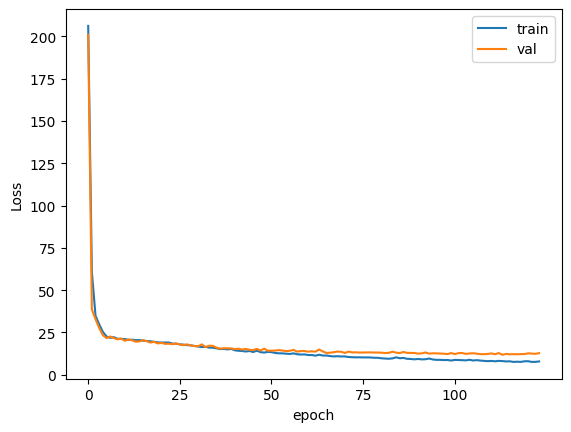

R² Train Score: 0.818
Train RMSE:     ±0.427
Train MAE:      ±0.310
R² Val Score: 0.643
Val RMSE:     ±0.595
Val MAE:      ±0.455


In [34]:
plt.plot(model.train_loss, label='train')
plt.plot(model.val_loss, label='val')

plt.legend()
plt.xlabel('epoch')
plt.ylabel('Loss')
plt.xticks(range(0, len(model.val_loss), 25))
plt.show()

model.eval()
model.analysis(train_loader, val_loader, device)

Train a custom model with ResGatedGraphConv layers (see ../models/gnn.py) to predict activity values

In [36]:
epochs = 500
model = gnn.ResGatedGraphConv(16, 256, 128, 16, 1).to(device)
model.fit(train_loader, val_loader, device, epochs=epochs) # early stopping applied

 30%|████████████████████████████████████████████████▉                                                                                                                  | 150/500 [07:11<16:47,  2.88s/it]


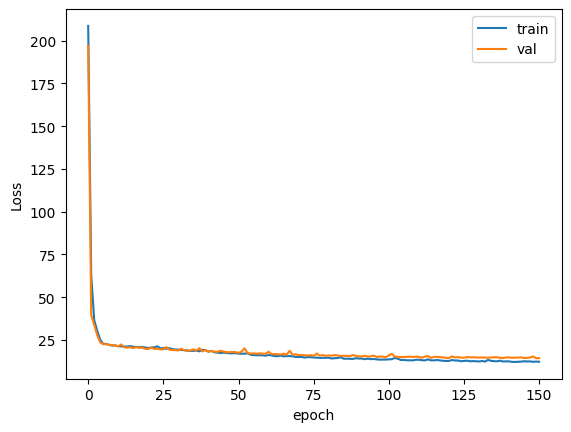

R² Train Score: 0.652
Train RMSE:     ±0.592
Train MAE:      ±0.422
R² Val Score: 0.542
Val RMSE:     ±0.674
Val MAE:      ±0.505


In [37]:
plt.plot(model.train_loss, label='train')
plt.plot(model.val_loss, label='val')

plt.legend()
plt.xlabel('epoch')
plt.ylabel('Loss')
plt.xticks(range(0, len(model.val_loss), 25))
plt.show()

model.eval()
model.analysis(train_loader, val_loader, device)

Train a custom model with GATConv layers (see ../models/gnn.py) to predict activity values

In [40]:
epochs = 500
model = gnn.GATConv(16, 256, 128, 16, 1).to(device)
model.fit(train_loader, val_loader, device, epochs=epochs, tol=0.3)

 40%|█████████████████████████████████████████████████████████████████▊                                                                                                 | 202/500 [26:21<38:52,  7.83s/it]


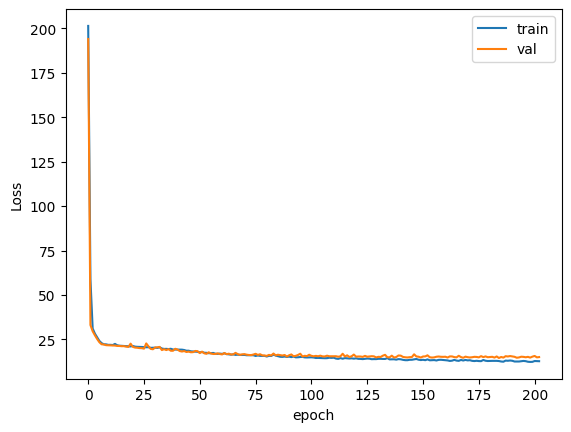

R² Train Score: 0.629
Train RMSE:     ±0.610
Train MAE:      ±0.440
R² Val Score: 0.517
Val RMSE:     ±0.692
Val MAE:      ±0.526


In [42]:
plt.plot(model.train_loss, label='train')
plt.plot(model.val_loss, label='val')

plt.legend()
plt.xlabel('epoch')
plt.ylabel('Loss')
plt.xticks(range(0, len(model.val_loss), 25))
plt.show()

model.eval()
model.analysis(train_loader, val_loader, device)